# Scripts

In [5]:
!python generate_data.py

Saving to: data/Heat
Total sampled parameters:  200
Training parameters:  160
Single sample run: 
Parametric heat equation finite element model
  Spatial domain (2D): [0, 6.2832] x [0, 6.2832]
  Discretization size: 1210
  Degrees of freedom:  1082
Run for all parameters:
no more timer available (lff_from_py), reusing last one


In [1]:
!python tucker.py

Saving to: data/Heat
Loading data
X.shape=(1082, 1201, 160)
Tucker
reconstruction error=0.032161601966420844, variation=3.088503624189276e-06.
converged in 2 iterations.
reconstruction error=0.006208299223683071, variation=8.393056642651275e-06.
converged in 2 iterations.
Tucker
reconstruction error=0.0003255253730619218, variation=9.478238045389654e-09.
converged in 2 iterations.
SVD
Saving SVD


# Import

In [1]:
import os
import numpy as np

os.chdir("../..")
savedir = "data/Heat"

In [2]:
import scipy.sparse as sp
from tensorly.tucker_tensor import TuckerTensor
from src.Heat.ROM import *
from src.Heat.FOM import HeatFEM2D
from src.Utils.utils import *
from src.Bases.rbf import RBFWeights
from src.Bases.lidw import lidw
import matplotlib.pyplot as plt

In [3]:
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}",
    "font.size": 20,
    "font.family": "serif",
    "axes.titlesize": 18,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

In [4]:
t = np.linspace(0, np.pi, 1201)
fom = HeatFEM2D(L=2 * np.pi, h=0.2, order=1)
M_Q = fom.M

In [5]:
with np.load(os.path.join(savedir, "params_train.npz")) as z:
    params_train = z["params"]
with np.load(os.path.join(savedir, "params_test.npz")) as z:
    params_test = z["params"]

with np.load(os.path.join(savedir, "heat_train.npz")) as z:
    snapshots_Q_train = z["Q"]

with np.load(os.path.join(savedir, "heat_test.npz")) as z:
    snapshots_Q_test = z["Q"]

snapshots_Q_train.shape, snapshots_Q_test.shape, params_train.shape, params_test.shape

((160, 1082, 1201), (40, 1082, 1201), (160, 3), (40, 3))

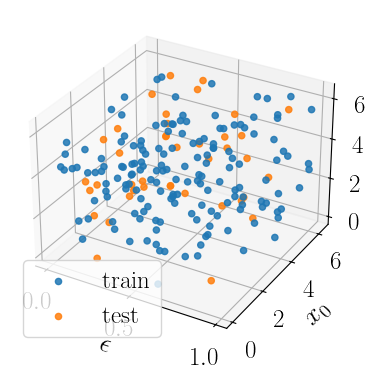

In [6]:
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(params_train[:,0], params_train[:,1], params_train[:,2],
           c="tab:blue", s=20, alpha=0.85, label="train")
ax.scatter(params_test[:,0],  params_test[:,1],  params_test[:,2],
           c="tab:orange", s=20, alpha=0.85, label="test")
ax.set_xlabel(r"$\epsilon$"); ax.set_ylabel("$x_0$"); ax.set_zlabel("$y_0$")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
data = np.load(os.path.join(savedir, "svd_rank120_Mortho.npz"))
U_mono, S_mono = data["U"], data["S"]
print("Check for MW-orthonormality: ||U^T MW U - I|| =",
      np.linalg.norm(U_mono.T @ M_Q @ U_mono - np.eye(U_mono.shape[1])))

Check for MW-orthonormality: ||U^T MW U - I|| = 2.2124748493665177e-14


In [8]:
core, factors = load_tucker_npz(os.path.join(savedir, "tucker_120x120x120_Mortho.npz"))
tucker_tensor = TuckerTensor((core, factors))
print("Tucker shape:", tucker_tensor.shape)

Tucker shape: (1082, 1201, 160)


In [9]:
r_arr = np.array([1, 5, 10, 20, 30, 40, 50, 60], dtype=int)

## Single run

In [10]:
rbfw = RBFWeights(
    mus=params_train,
    basis="gaussian",
    eps=1,
    order=-1,
    nugget=0,
)

In [11]:
idx       = 8
r_idx_rbf = 2
r_idx_lid = 2
r_idx_mono = 2

mu = params_test[idx]   # [omega, x0, y0]
print(f"mu: eps={mu[0]:.3f}, x0={mu[1]:.3f}, y0={mu[2]:.3f}")

mu: eps=0.334, x0=5.807, y0=5.418


In [12]:
W_rbf = rbfw.weights(params_test[idx])
U_rbf, s_rbf, _ = buildParBasis(tucker_tensor, W_rbf)

print("MW-orthonormality: ||U^T MW U - I|| =",
      np.linalg.norm(U_rbf.T @ M_Q @ U_rbf - np.eye(U_rbf.shape[1])))
print("Projection error  :", projection_error_M(snapshots_Q_test[idx],
      U_rbf[:, :r_arr[r_idx_rbf]], M_Q, Mnorm))

ROM_rbf = HeatPODROM(fom, U_rbf[:, :r_arr[r_idx_rbf]])
Qr_rbf, Ur_rbf = ROM_rbf.solve(mu[0], mu[1], mu[2], t)
Q_rbf = Ur_rbf @ Qr_rbf

print("ROM error (MW)    :",
      Mnorm(snapshots_Q_test[idx] - Q_rbf, M_Q) / Mnorm(snapshots_Q_test[idx], M_Q))
U_rbf[:, :r_arr[r_idx_rbf]].shape

MW-orthonormality: ||U^T MW U - I|| = 2.8208156025847085e-14
Projection error  : 0.11282754661878222
ROM error (MW)    : 0.11550286468217254


(1082, 10)

In [13]:
ROM_mono = HeatPODROM(fom, U_mono[:, :r_arr[r_idx_mono]])
Qr_mono, Ur_mono = ROM_mono.solve(mu[0], mu[1], mu[2], t)
Q_mono = Ur_mono @ Qr_mono

print("MW-orthonormality: ||U^T MW U - I|| =",
      np.linalg.norm(Ur_mono.T @ M_Q @ Ur_mono - np.eye(Ur_mono.shape[1])))
print("Projection error  :", projection_error_M(snapshots_Q_test[idx],
      Ur_mono, M_Q, Mnorm))
print("ROM error (MW)    :",
      Mnorm(snapshots_Q_test[idx] - Q_mono, M_Q) / Mnorm(snapshots_Q_test[idx], M_Q))


MW-orthonormality: ||U^T MW U - I|| = 4.85185037480557e-15
Projection error  : 0.6860302655999331
ROM error (MW)    : 0.7107849653162872


In [14]:
W_lid = lidw(params_train, 15, params_test[idx], eps=1e-16, rcond=1e-16)
U_lid, s_lid, _ = buildParBasis(tucker_tensor, W_lid)

print("MW-orthonormality: ||U^T MW U - I|| =",
      np.linalg.norm(U_lid[:, :r_arr[r_idx_lid]].T @ M_Q @ U_lid[:, :r_arr[r_idx_lid]] - np.eye(r_arr[r_idx_lid])))
print("Projection error  :", projection_error_M(snapshots_Q_test[idx],
      U_lid[:, :r_arr[r_idx_lid]], M_Q, Mnorm))

ROM_lid = HeatPODROM(fom, U_lid[:, :r_arr[r_idx_lid]])
Qr_lid, Ur_lid = ROM_lid.solve(mu[0], mu[1], mu[2], t)
Q_lid = Ur_lid @ Qr_lid

print("ROM error (MW)    :",
      Mnorm(snapshots_Q_test[idx] - Q_lid, M_Q) / Mnorm(snapshots_Q_test[idx], M_Q))


MW-orthonormality: ||U^T MW U - I|| = 4.398095537701698e-15
Projection error  : 0.14635881940442583
ROM error (MW)    : 0.14914206862569424


# Plots

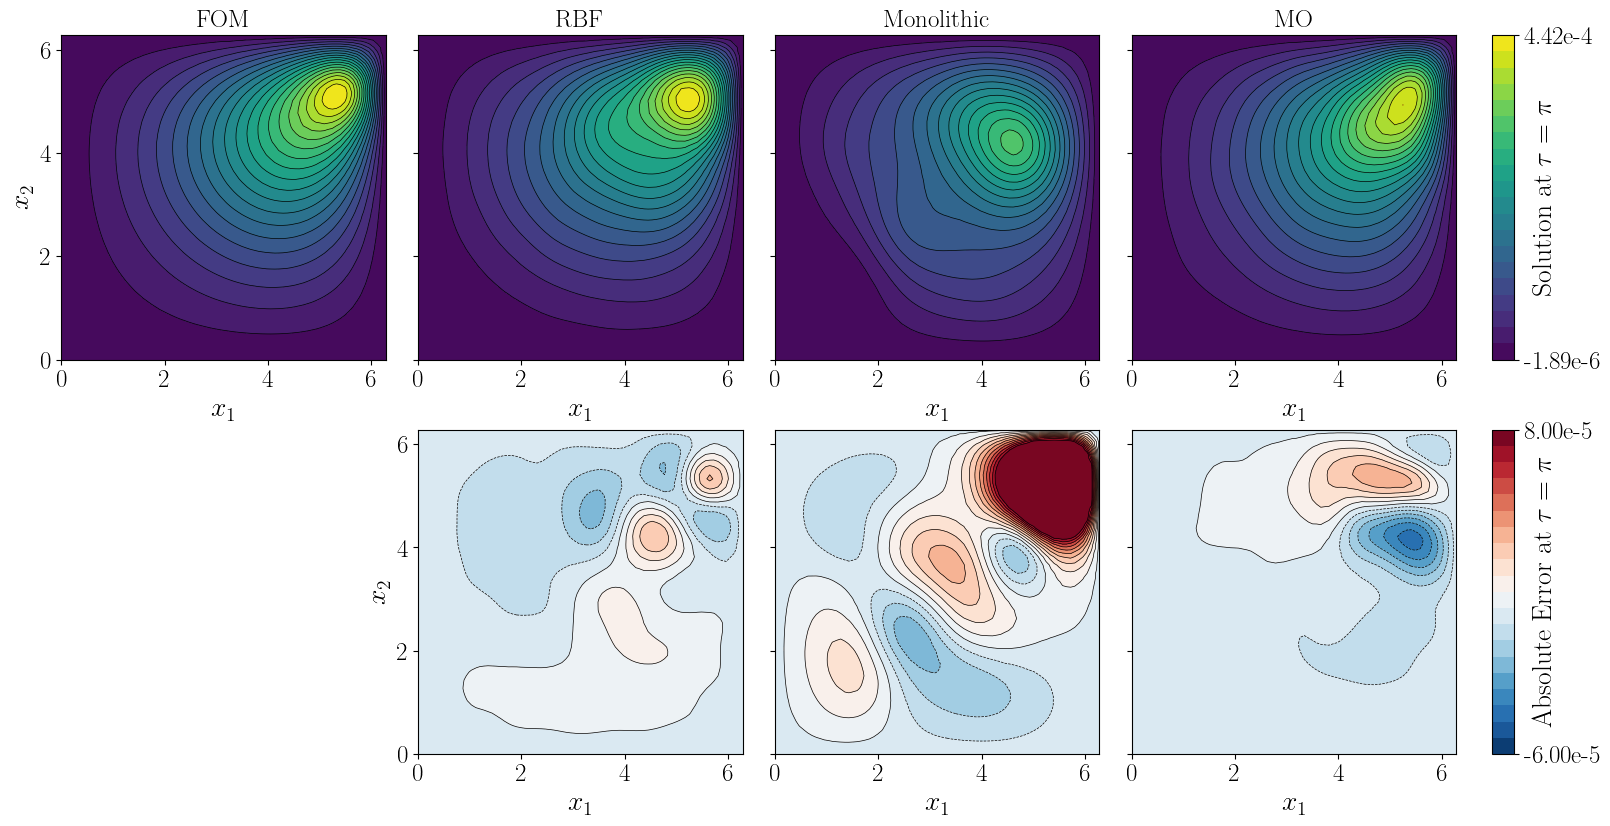

In [15]:
from src.Heat.plots import eval_grid, plot_contours

t_idx = -1

Z_fom  = eval_grid(fom, snapshots_Q_test[idx][:, t_idx])
Z_rbf  = eval_grid(fom, Q_rbf[:, t_idx])
Z_mono = eval_grid(fom, Q_mono[:, t_idx])
Z_lid  = eval_grid(fom, Q_lid[:, t_idx])

plot_contours(fom, Z_fom, Z_rbf, Z_mono, Z_lid,
              sol_label=rf"Solution at $\tau = \pi$",
              err_label=rf"Absolute Error at $\tau = \pi$",
            nlevels=20, eclims=[-6e-5, 8e-5])
plt.savefig("solution_heat.pdf", bbox_inches='tight')
plt.show()


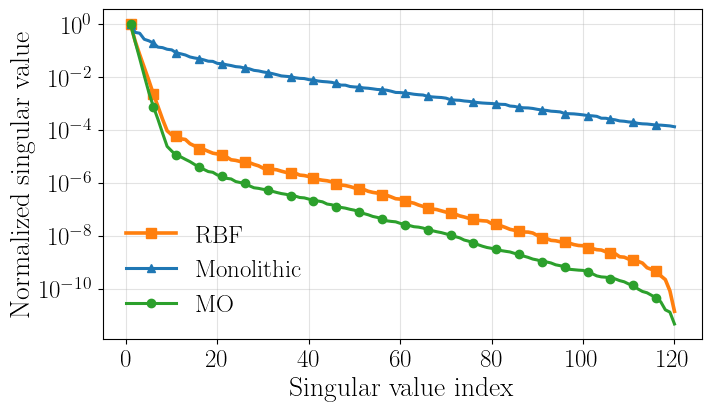

In [18]:
from src.Heat.plots import plot_singular_values


plot_singular_values(s_rbf, S_mono, s_lid)
plt.savefig("singular_values_heat.pdf", bbox_inches='tight')
plt.show()


In [20]:
import tensorly as tl

X_orig = snapshots_Q_train.transpose(1, 2, 0)
X_norm = np.linalg.norm(X_orig)

for rank_str, npz_file in [("30x30x30",   "tucker_30x30x30_Mortho.npz"),
    ("60x60x60",   "tucker_60x60x60_Mortho.npz"),
                            ("120x120x120", "tucker_120x120x120_Mortho.npz")]:
    c, f = load_tucker_npz(os.path.join(savedir, npz_file))
    X_rec = tl.tucker_to_tensor((c, f))
    err = np.linalg.norm(X_orig - X_rec) / X_norm
    print(f"Tucker ({rank_str})  rel. reconstruction error = {err:.4e}")


Tucker (30x30x30)  rel. reconstruction error = 3.3286e-02
Tucker (60x60x60)  rel. reconstruction error = 6.5833e-03
Tucker (120x120x120)  rel. reconstruction error = 3.6343e-04


# Parameter sweep

In [14]:
def heat_sweep_dataset(fom, params, r_arr, snapshots_Q, t, M_Q,
                       basis_builder, label=""):
    """ROM and projection-error sweep over a dataset.

    Returns
    -------
    rom_Q  : (len(r_arr), n_cases) – relative M ROM error
    proj_Q : (len(r_arr), n_cases) – relative M projection error
    """
    r_arr   = np.asarray(r_arr, dtype=int)
    rmax    = int(np.max(r_arr))
    n_cases = params.shape[0]

    rom_Q  = np.zeros((len(r_arr), n_cases))
    proj_Q = np.zeros((len(r_arr), n_cases))

    for idx in range(n_cases):
        mu      = params[idx]
        Q_truth = snapshots_Q[idx]          # (Nx_free, Nt)
        denom   = Mnorm(Q_truth, M_Q)

        U_max = basis_builder(mu, rmax)
        ROM   = HeatPODROM(fom, U_max)

        for r_idx, r in enumerate(r_arr):
            Qr, Ur = ROM.solve(mu[0], mu[1], mu[2], t, r=int(r))
            Q_full = Ur @ Qr
            rom_Q [r_idx, idx] = Mnorm(Q_truth - Q_full, M_Q) / denom
            proj_Q[r_idx, idx] = projection_error_M(Q_truth, Ur, M_Q, Mnorm)

        if label:
            print(f"{label}: {idx+1}/{n_cases}", end="\r")
    print()
    return rom_Q, proj_Q


# Basis builders (return (Nx_free, rmax) basis for a given mu)
def build_mono(mu, rmax):
    return U_mono[:, :rmax]

def build_rbf(mu, rmax):
    W = rbfw.weights(mu)
    U, _, _ = buildParBasis(tucker_tensor, W)
    return U[:, :rmax]

def build_lid(mu, rmax, k=15, eps=1e-16, rcond=1e-16):
    W = lidw(params_train, k, mu, eps=eps, rcond=rcond)
    U, _, _ = buildParBasis(tucker_tensor, W)
    return U[:, :rmax]


In [15]:
mono_rom_te, mono_proj_te = heat_sweep_dataset(
    fom, params_test, r_arr, snapshots_Q_test, t, M_Q, build_mono, label="mono test")

rbf_rom_te, rbf_proj_te = heat_sweep_dataset(
    fom, params_test, r_arr, snapshots_Q_test, t, M_Q, build_rbf, label="rbf test")

lid_rom_te, lid_proj_te = heat_sweep_dataset(
    fom, params_test, r_arr, snapshots_Q_test, t, M_Q, build_lid, label="lid test")

mono test: 40/40
rbf test: 40/40
lid test: 40/40


In [16]:
mono_rom_tr, mono_proj_tr = heat_sweep_dataset(
    fom, params_train, r_arr, snapshots_Q_train, t, M_Q, build_mono, label="mono train")

rbf_rom_tr, rbf_proj_tr = heat_sweep_dataset(
    fom, params_train, r_arr, snapshots_Q_train, t, M_Q, build_rbf, label="rbf train")

lid_rom_tr, lid_proj_tr = heat_sweep_dataset(
    fom, params_train, r_arr, snapshots_Q_train, t, M_Q, build_lid, label="lid train")

mono train: 160/160
rbf train: 160/160
lid train: 160/160


In [17]:
np.savez(
    os.path.join(savedir, "errors_120x120x120.npz"),
    r_arr=r_arr,
    params_train=params_train,
    params_test=params_test,

    mono_rom_train=mono_rom_tr,  mono_proj_train=mono_proj_tr,
    mono_rom_test=mono_rom_te,   mono_proj_test=mono_proj_te,

    rbf_rom_train=rbf_rom_tr,    rbf_proj_train=rbf_proj_tr,
    rbf_rom_test=rbf_rom_te,     rbf_proj_test=rbf_proj_te,

    lid_rom_train=lid_rom_tr,    lid_proj_train=lid_proj_tr,
    lid_rom_test=lid_rom_te,     lid_proj_test=lid_proj_te,
)

/Users/arjunveejay/Documents/Code/Private repos/TuckerROMs/src/Heat/plots.py:73: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.16)


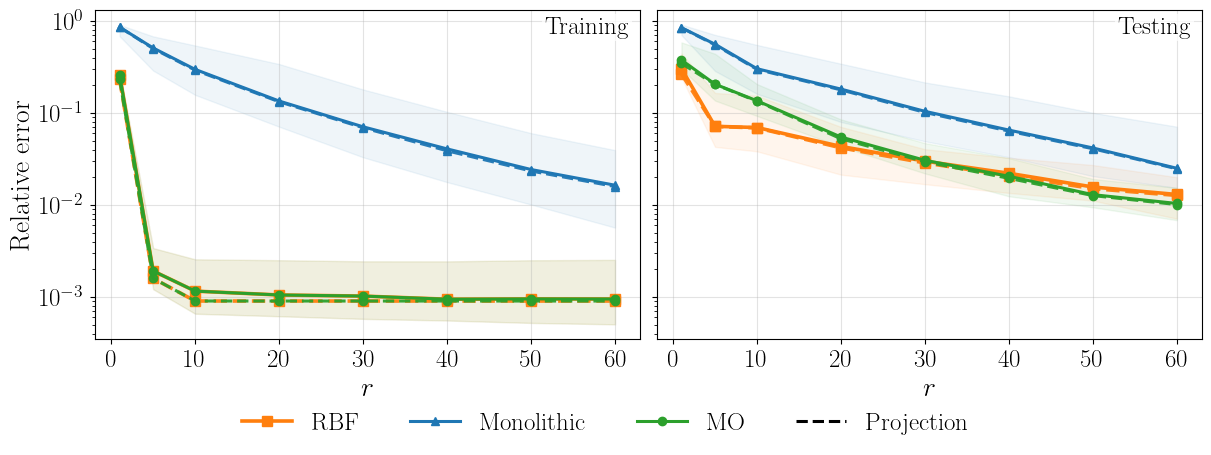

In [4]:
# Tucker ranks (120, 120, 120)
from src.Heat.plots import plot_errors
errs = np.load(os.path.join(savedir, "errors_120x120x120.npz"))
plot_errors(errs)
plt.savefig("errors_heat.pdf", bbox_inches='tight')
plt.show()


/Users/arjunveejay/Documents/Code/Private repos/TuckerROMs/src/Heat/plots.py:73: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.16)


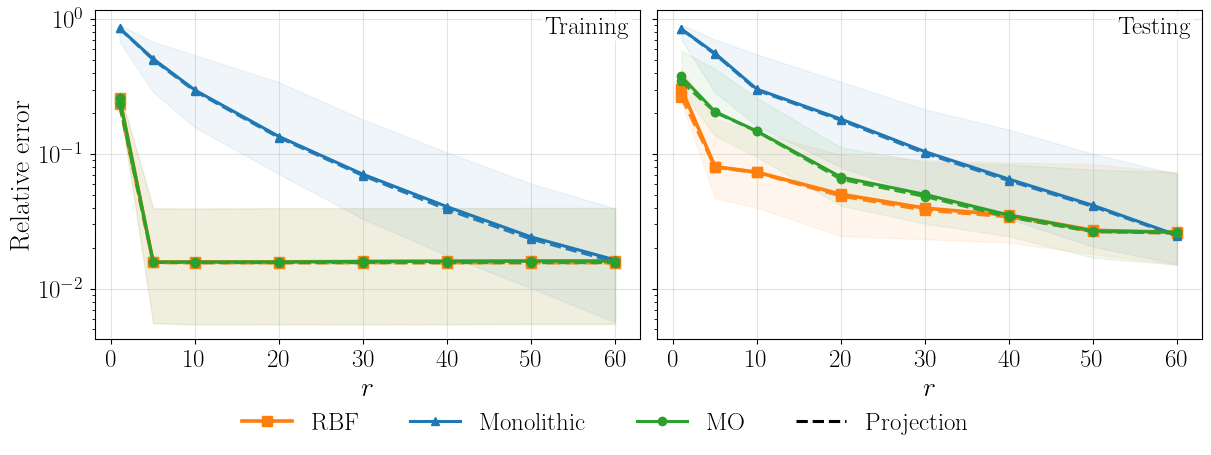

In [5]:
# Tucker ranks (60, 60, 60)
errs = np.load(os.path.join(savedir, "errors_60x60x60.npz"))
plot_errors(errs)
plt.show()


In [28]:
import tensorly as tl

X_orig   = snapshots_Q_train.transpose(1, 2, 0)
X_mat    = X_orig.reshape(X_orig.shape[0], -1)
X_norm_M = Mnorm(X_mat, M_Q)

tucker_configs = [
    ("30x30x30",    "tucker_30x30x30_Mortho.npz",    30),
    ("60x60x60",    "tucker_60x60x60_Mortho.npz",    60),
    ("120x120x120", "tucker_120x120x120_Mortho.npz", 120),
]

print(f"{'Tucker rank':<15}  {'Recon error':>12}  {'Method':<12}  {'Train':>10}  {'Test':>10}")
print("-" * 68)

for rank_str, npz_file, rmax in tucker_configs:
    c, f = load_tucker_npz(os.path.join(savedir, npz_file))
    tt = TuckerTensor((c, f))

    X_rec   = tl.tucker_to_tensor((c, f))
    E_mat   = (X_orig - X_rec).reshape(X_orig.shape[0], -1)
    recon   = Mnorm(E_mat, M_Q) / X_norm_M

    bases = {
        "Monolithic": lambda mu, tt=tt, r=rmax: U_mono[:, :r],
        "RBF":        lambda mu, tt=tt, r=rmax: buildParBasis(tt, rbfw.weights(mu))[0][:, :r],
        "MO":         lambda mu, tt=tt, r=rmax: buildParBasis(tt, lidw(params_train, 15, mu, eps=1e-16, rcond=1e-16))[0][:, :r],
    }

    for i, (method, builder) in enumerate(bases.items()):
        tr = np.median([projection_error_M(snapshots_Q_train[j], builder(params_train[j]), M_Q, Mnorm)
                        for j in range(len(params_train))])
        te = np.median([projection_error_M(snapshots_Q_test[j],  builder(params_test[j]),  M_Q, Mnorm)
                        for j in range(len(params_test))])
        recon_str = f"{recon:.4e}" if i == 0 else ""
        print(f"{rank_str:<15}  {recon_str:>12}  {method:<12}  {tr:>10.4e}  {te:>10.4e}")
    print()


Tucker rank       Recon error  Method             Train        Test
--------------------------------------------------------------------
30x30x30           3.2162e-02  Monolithic    6.9086e-02  1.0129e-01
30x30x30                       RBF           6.9105e-02  1.0139e-01
30x30x30                       MO            6.9105e-02  1.0139e-01

60x60x60           6.2083e-03  Monolithic    1.5852e-02  2.4694e-02
60x60x60                       RBF           1.5626e-02  2.5946e-02
60x60x60                       MO            1.5626e-02  2.5946e-02

120x120x120        3.2553e-04  Monolithic    9.0248e-04  3.7405e-03
120x120x120                    RBF           9.0169e-04  3.7351e-03
120x120x120                    MO            9.0169e-04  3.7351e-03

